## **Exercise 1 (Pitfalls in t-SNE, 12 Points)**

t-SNE is a technique that is able to create two-dimensonal “maps” from really high-dimensional data. It uses a non-linear algorithm that performs different transformations on different regions. An important parameter of t-SNE is *perplexity*, which says how to balance attention between local and global aspects of your data. The parameter is, in a sense, a guess about the number of close neighbors each point has.

### **a) Three clusters, 10 points/class, 50 dimensions**

In this part of the exercise we will be running the demo of 3 clusters of 10 points each with perplexity=29 and with perplexity=30. We will try to comprehend the difference in the final 2D embeddings.



Embedding with perplexity=29:

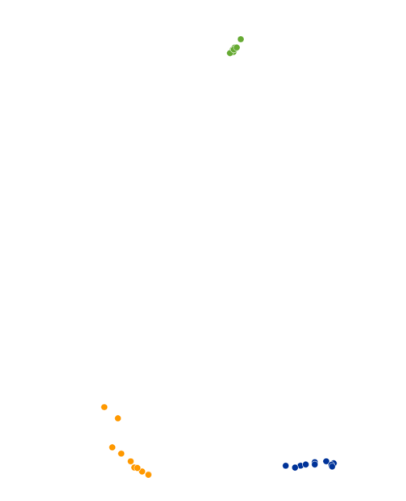



Embedding with perplexity=30:

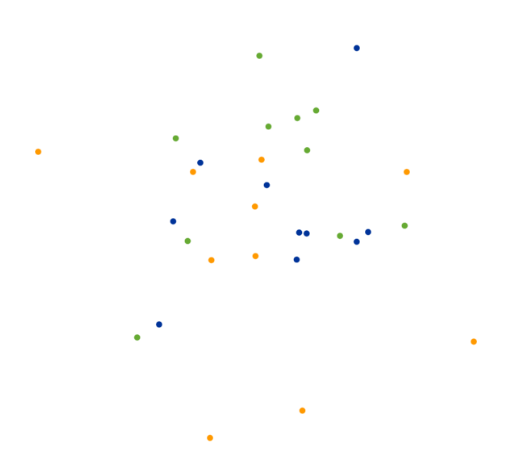


We notice that we have $3\times 10=30$ points in out dataset. 

It is important to take into account that t-SNE relies on local neighborhoods and that perplexity reflects the effective number of neighbors.

When the perplexity is set to 29, each point effectively treats almost all other points as neighbors. We can tell that some local structure is preserved but they are really contracted bceause it is what the algorithm does to high density regions when paying attention to the global structure. 

But when the perplexity is 30, the perplexity is equal to the total number of points in the dataset. The neighborhood probabilities become almost uniform.Here the clusters are merged and it is because the t-SNE algorithm needs a smaller perplexity than the number of points to operate properly. The algorithm no longer captures local structure and the embedding changes abruptly.

### **b) Square grid, 20 points/side, perplexity = 100**

Now we will be using a square grid with equal spacing between points. We should analyze why are distances between points in the middle of the
square larger than near the boundary.

Plot with perplexity = 100:

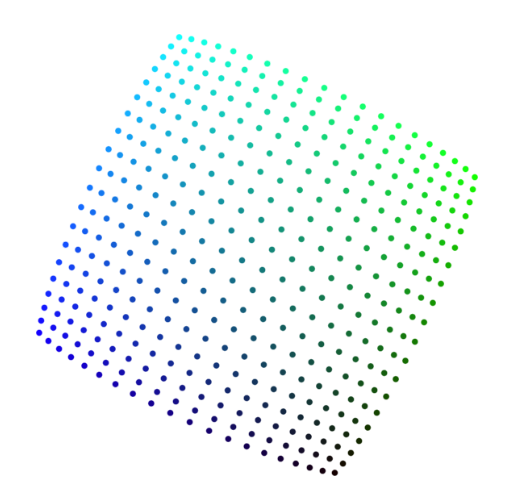

In this case, all points are originally evenly spaced on a grid. But in the t-SNE embedding we can tell that distances between central points become larger, while distances near the boundary become compressed.

This happens because, every time we get more into the center, the points have many more neighbors in all directions. This involves that the local neighborhood density is growing when we approach the center of the grid. But boundary points have fewer nearby neighbors, therefore, the borders of the grid are lower denisity regions.

t-SNE tries to preserve neighborhood probabilities rather than true Euclidean distances. Consequently, to represent the high-density regions correctly in 2 dimensions, the optimization increases spacing between points in these areas to avoid overcrowding. In conclusion, interior points spread apart because they have many equally close neighbors, while edge points can stay closer together due to fewer neighborhood constraints.


### **c) Square grid, 20 points/side, perplexity = 2**

We will be using same data as in the last part but with perplexity=2. Some of the embedding we obtained running the demo are:

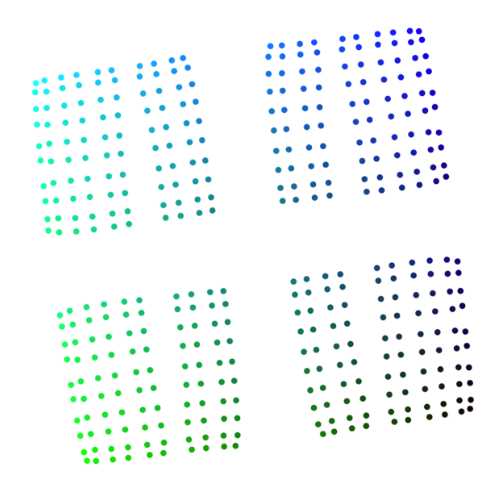

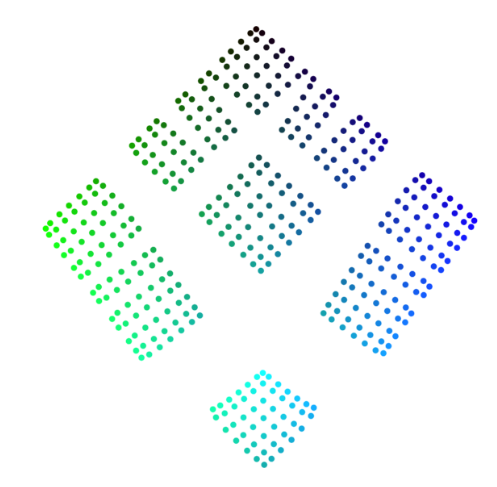

Because the perplexity is really small, each point only considers a very tiny number of neighbors as important. The algorithm focuses almost entirely on extremely local relationships. Therefore, the global stucture is almost ignored and neighbor relations become unstable. Another consequence is that global connectivity is lost.

Moreover, different local groups may drift apart during gradient descent. This is because t-SNE optimization is non-convex, so different runs can converge to different local minimums.


### **d) Random points in a circle, 100 points**

We will analyze with what perplexity the embedding looks more like the original data.

Perplexity=10

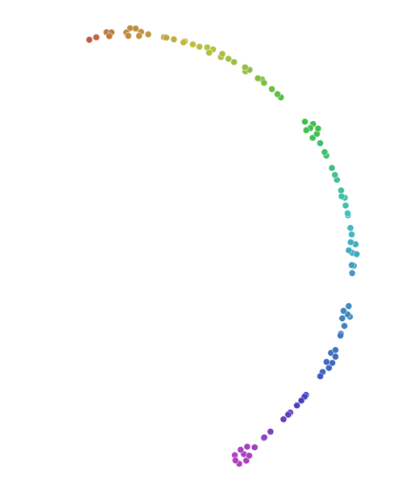


Perplexity=13

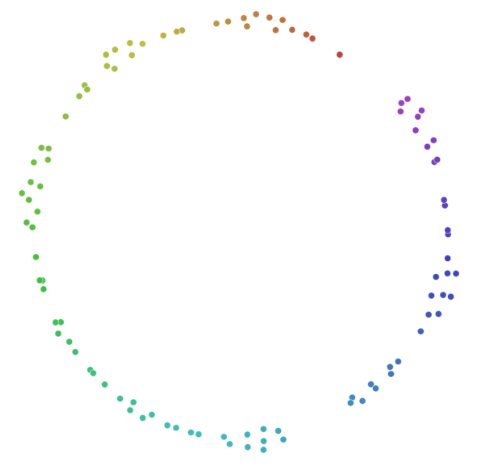


Perplexity=30

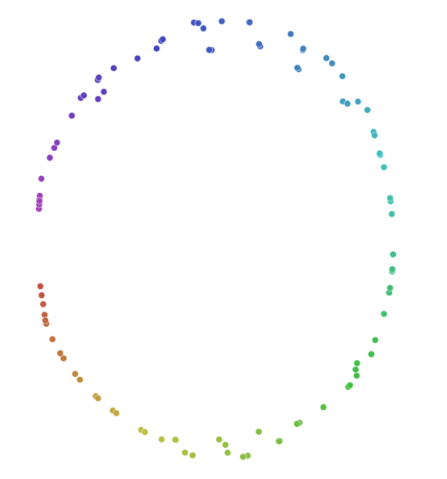


Perplexity=50

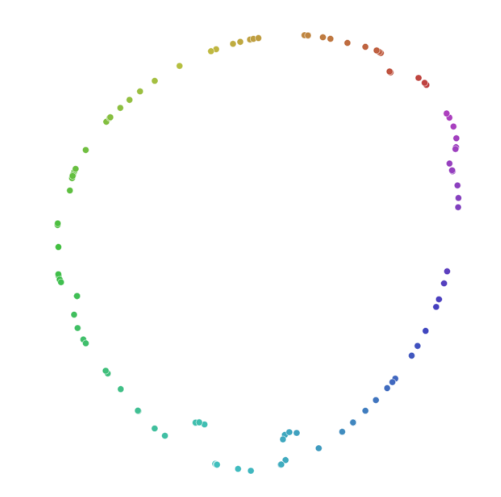


Perplexity=90

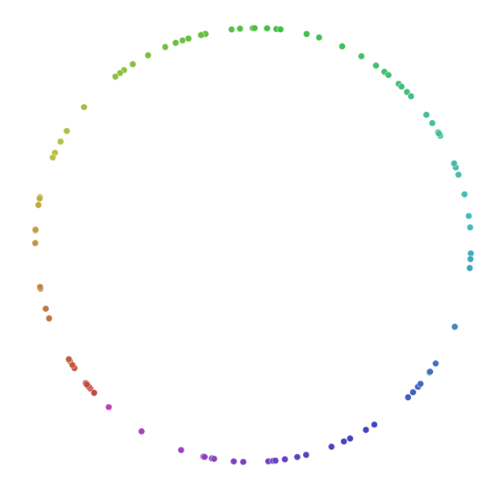


We can tell that with perplexity=10 the global structure is not preserved at all. The global geometry is completely distorted because the algorithm focuses too much on local neighborhoods and the differents densities of the distribution due to the randomness of it. However, at perplexity=13 we can start seeing the roundness and continuity of the circle again, but some unreal clusters and gaps are still exaggerated because of the differences of density in the original random distribution. 

When we start increasing the perplexity, for example at perplexity=30, we can see how this clusters starts 'disolving'. A similar result is obtained with perplexity=50, where the roundness of the circle is a little bit lost but the spreadness of the points is more precise. We could tell that these perplexities incorpoate enough global information so that the t-SNE begins preserving the overall circular manifold structure.

At a really high perplexity=90, the original struture is completely preserved but the information of the different density areas is less reflected.